# Exploratory Data Analysis (EDA) — Healthcare Dataset
## Assignment 1: Exploratory Data Analysis (From Data to Understanding)
**Course:** Introduction to Data Science
**Lecturer:** Dr. Uri Itai | **TA:** Hanit Ohayon Hadad | **Grader:** Dror Meirovich
**HIT — Holon Institute of Technology, Faculty of Computer Science**

**Student Name:** _Reshef Kononovich_
**Student ID:** _318721230_






## 2. Dataset Selection

### 2.1 Requirements Check
- Tabular data ✔️
- 1000+ rows ✔️ (55,500 rows)
- 10+ columns ✔️ (15 columns)
- Mix of numerical, temporal, and categorical variables ✔️

### 2.2 Data Source Description

- **Source**: [Healthcare Dataset](https://www.kaggle.com/datasets/prasad22/healthcare-dataset) on Kaggle (mirrored on
  [GitHub](https://github.com/imranbdcse/healthcaredatasets) for direct download).
- **Collection purpose**: The dataset was explicitly created as a *synthetic* (artificially generated) dataset for
  educational and portfolio purposes — to let students and practitioners train, test, and learn data analysis /
  machine learning techniques on healthcare-like data without any real patient privacy concerns.
- **Collecting entity**: Not a real hospital or health organization. Created by a Kaggle user (Prasad Patil) as a
  practice dataset, most likely generated using a synthetic-data library .
- **Domain knowledge note**: Because the data is synthetic, it *mimics* the structure of real Electronic Health
  Record (EHR) / hospital admission data (patient demographics, admission/discharge dates, billing, medical
  condition, medication, test results) but the actual values are **randomly generated** and not drawn from any
  real clinical process. This is an important fact we will keep testing throughout the analysis: synthetic data
  is often *"too clean"* or *too uniform* compared to real-world data, and part of our job is to look for evidence
  of that.



In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [ ]:
# Load the dataset directly from its source (works out-of-the-box on Google Colab,
# no manual upload needed). If you prefer working with a local copy, download the file
# once and change DATA_PATH to "healthcare_dataset.csv".
DATA_URL = "https://raw.githubusercontent.com/imranbdcse/healthcaredatasets/DataScience/healthcare_dataset.csv"
DATA_PATH = DATA_URL

df = pd.read_csv(DATA_PATH)
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 3. Meta-Analysis of the Data

### 3.1 File Analysis


In [ ]:
import urllib.request

# File size: fetched via HTTP headers when loading from a URL, or from disk if using a local file
if DATA_PATH.startswith("http"):
    with urllib.request.urlopen(DATA_PATH) as response:
        file_size_bytes = int(response.headers.get("Content-Length", 0))
else:
    import os
    file_size_bytes = os.path.getsize(DATA_PATH)

file_size_mb = file_size_bytes / (1024 ** 2)

print(f"File size: {file_size_mb:.2f} MB ({file_size_bytes:,} bytes)")
print(f"File format: CSV (comma-separated values)")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")


File size: 8.01 MB (8,399,221 bytes)
File format: CSV (comma-separated values)
Number of rows: 55,500
Number of columns: 16


**File creation date**: Not embedded in the CSV itself (CSV files don't carry creation-date metadata the way
some binary formats do). Based on the source page, the dataset was last updated in 2024 on Kaggle.

**Purpose of the data**: Explicitly educational — to practice data cleaning, EDA, visualization and predictive
modeling in a healthcare-like context, without using real patient data.

### 3.2 Data Structure

This is our first real look at the data: its shape, column names, and data types.


In [41]:
print("Shape (rows, columns):", df.shape)
df.columns.tolist()


Shape (rows, columns): (55500, 16)


['Name',
 'Age',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Billing Amount',
 'Room Number',
 'Admission Type',
 'Discharge Date',
 'Medication',
 'Test Results',
 'Length of Stay']

In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

**Column names — do they make sense?**

The column names are descriptive and self-explanatory (`Age`, `Gender`, `Medical Condition`, `Date of Admission`,
etc.), written in plain English with title-case and no cryptic abbreviations. This readability is itself a clue
that the dataset was designed for teaching purposes rather than exported from a real hospital's internal system
(real EHR exports typically use coded/abbreviated column names, e.g. `pat_dob`, `adm_dt`, ICD codes, etc.).

**Data types — any insights?**

Running `df.info()` shows that `Date of Admission` and `Discharge Date` are loaded as plain `object` (string)
columns rather than `datetime`. This is very common when reading raw CSVs — pandas doesn't parse dates
automatically — so we convert them explicitly below. Everything else looks reasonable at first glance
(`Age`/`Room Number` as integers, `Billing Amount` as float, the rest as categorical/text `object` columns).


In [43]:
# Convert date columns to proper datetime dtype
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Derived feature we will use throughout the notebook: length of stay (in days)
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

df[['Date of Admission', 'Discharge Date', 'Length of Stay']].describe()


,Date of Admission,Discharge Date,Length of Stay
count,55500,55500,55500.000000
mean,2021-11-01 01:02:22.443243008,2021-11-16 13:15:20.821621504,15.509009
min,2019-05-08 00:00:00,2019-05-09 00:00:00,1.000000
25%,2020-07-28 00:00:00,2020-08-12 00:00:00,8.000000
50%,2021-11-01 00:00:00,2021-11-17 00:00:00,15.000000
75%,2023-02-03 00:00:00,2023-02-18 00:00:00,23.000000
max,2024-05-07 00:00:00,2024-06-06 00:00:00,30.000000
std,NaN,NaN,8.659600


**Discussion: research vs. operational data, and possible biases**

This dataset was **not** collected as part of an actual research study or hospital operation — it's synthetic
data generated for teaching. That matters a lot for how we interpret every later result:

- There is no real underlying patient population, so distributions (age, condition, cost) don't reflect real
  epidemiology — any "pattern" we find is a property of the *generator*, not of real healthcare.
- Because it isn't tied to a real institution, there's no realistic correlation structure between fields the way
  there would be in real EHR data (e.g. real hospitals would show relationships between condition severity, length
  of stay, and cost that a naive random generator may not reproduce faithfully).
- We should be careful not to draw real clinical conclusions from this data — our insights are about *data
  analysis technique*, not about actual healthcare policy.


## 4. Data Quality and Completeness

### 4.1 Missing Data


In [45]:
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
if missing_summary['missing_count'].sum() > 0:
    display(missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False))
else:
    print("No missing values found in any column.")
missing_summary


No missing values found in any column.


,missing_count,missing_pct
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Blood Type,0,0.0
Medical Condition,0,0.0
Date of Admission,0,0.0
Doctor,0,0.0
Hospital,0,0.0
Insurance Provider,0,0.0
Billing Amount,0,0.0


**Extent, pattern, and interpretation of missingness**

There are **zero missing values** across all 55,500 rows and 15 columns. For a real-world healthcare dataset this
would be unusually clean — administrative fields like `Insurance Provider`, `Doctor`, or `Room Number` are almost
always missing in some rows in practice. The complete absence of missing data is further evidence that this is a
**synthetically generated** dataset (the generator simply always filled every field), rather than the accidental
absence of missingness in a real one.

**How would we handle missing data if it existed?** For this dataset it's moot, but as a general approach: numeric
fields could be imputed with median/mean (robust to outliers) or a model-based imputation; categorical fields with
a dedicated `"Unknown"` category (safer than mode-imputation, which can hide the fact that data was missing);
and if missingness were structured (e.g. always missing for one hospital), that pattern itself would be
investigated before imputing anything.

### 4.2 Duplicates


In [46]:
full_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates} ({full_duplicates/len(df)*100:.2f}% of the data)")

# A more meaningful "partial duplicate" definition for this domain: same patient identity
# (Name + Age + Gender) admitted under the same condition on the same date — likely a data
# generation artifact rather than a real repeat admission.
partial_dup_cols = ['Name', 'Age', 'Gender', 'Medical Condition', 'Date of Admission']
partial_duplicates = df.duplicated(subset=partial_dup_cols).sum()
print(f"Partial duplicates (same {partial_dup_cols}): {partial_duplicates} "
      f"({partial_duplicates/len(df)*100:.2f}% of the data)")

df[df.duplicated(keep=False)].sort_values('Name').head(6)


Fully duplicated rows: 534 (0.96% of the data)
Partial duplicates (same ['Name', 'Age', 'Gender', 'Medical Condition', 'Date of Admission']): 534 (0.96% of the data)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
54285,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal,29
42407,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal,29
26025,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive,27
53104,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive,27
50151,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal,28
42323,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal,28


**What can we infer from the duplicates?**

The ~1% fully-duplicated rows are almost certainly an artifact of how the synthetic generator sampled random
combinations of (fairly limited) categorical value pools — with enough rows, the same random combination of name,
age, condition, doctor, etc. eventually repeats by chance, especially for common names generated by the underlying
Faker-like library. This is different from a real hospital dataset, where an exact duplicate row would more likely
indicate a genuine data-entry/export error (e.g. the same admission record exported twice).

**Should we drop them?** For this assignment we keep a copy of the *cleaned* (deduplicated) data for statistics
that assume independent observations (e.g. correlation, distribution shape), while keeping the *original* data
available for anything explicitly about the raw file (like this quality assessment itself). We deduplicate on the
full row basis, since keeping true full-row duplicates would silently double-count some records in later
aggregations.


In [ ]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Original rows: {len(df):,} -> After removing full duplicates: {len(df_clean):,}")


Original rows: 55,500 -> After removing full duplicates: 54,966


### 4.3 Suspicious Values


In [48]:
# Impossible / out-of-range values
print("Age range:", df['Age'].min(), "-", df['Age'].max())
print("Billing Amount range:", df['Billing Amount'].min(), "-", df['Billing Amount'].max())
print("Room Number range:", df['Room Number'].min(), "-", df['Room Number'].max())
print()
print("Negative billing amounts:", (df['Billing Amount'] < 0).sum())
print("Zero or negative age:", (df['Age'] <= 0).sum())
print("Rows where Discharge Date is before Date of Admission:",
      (df['Discharge Date'] < df['Date of Admission']).sum())
print("Rows with Length of Stay == 0 (same-day discharge):", (df['Length of Stay'] == 0).sum())


Age range: 13 - 89
Billing Amount range: -2008.4921398591305 - 52764.276736469175
Room Number range: 101 - 500

Negative billing amounts: 108
Zero or negative age: 0
Rows where Discharge Date is before Date of Admission: 0
Rows with Length of Stay == 0 (same-day discharge): 0


We specifically check for **negative billing amounts** — since `Billing Amount` is a cost, negative values
would be impossible/suspicious (unless representing a refund, which isn't documented as a possibility here).
We also check that discharge always happens on/after admission (a basic logical constraint), and look at
same-day admissions as a plausible-but-worth-flagging edge case rather than an error.

**Findings**: `Age` ranges from a plausible 13 to 89 (no zero/negative ages). `Room Number` stays within a
sensible 101–500 range. However, **108 rows (~0.2% of the data) have a negative `Billing Amount`**, down to about
-$2,008 — this is impossible for a billed amount and is a clear data-quality issue, not a real refund (there is
no `Transaction Type` or `Refund` flag in the schema to justify a negative charge). This is best explained as
noise from the synthetic-data generator rather than a real accounting event, and should be treated as an invalid
value: for downstream analysis (e.g. correlation and billing-related aggregates in Section 6) we either exclude
these 108 rows or clip them, and we flag this decision explicitly rather than silently ignoring it. On the
logical-consistency side, `Discharge Date` is **never** earlier than `Date of Admission` (0 violations), and there
are **no same-day discharges** (`Length of Stay == 0` never occurs) — length of stay ranges from 1 to 30 days,
which looks like a deliberately bounded random range rather than a naturally occurring clinical distribution.


In [ ]:
# Negative billing amounts: closer look
neg_billing = df[df['Billing Amount'] < 0]
print(f"Rows with negative Billing Amount: {len(neg_billing)} ({len(neg_billing)/len(df)*100:.2f}% of data)")
neg_billing[['Age', 'Medical Condition', 'Admission Type', 'Billing Amount']].describe()


Rows with negative Billing Amount: 108 (0.19% of data)


,Age,Billing Amount
count,108.000000,108.000000
mean,52.009259,-499.301242
std,19.897633,426.463202
min,18.000000,-2008.492140
25%,33.000000,-792.084802
50%,50.500000,-369.093816
75%,68.250000,-153.079565
max,85.000000,-23.866729


### 4.4 Cardinality


In [50]:
cardinality = df.nunique().sort_values()
cardinality_pct = (cardinality / len(df) * 100).round(2)
pd.DataFrame({'unique_values': cardinality, 'pct_of_rows': cardinality_pct})


,unique_values,pct_of_rows
Gender,2,0.00
Admission Type,3,0.01
Test Results,3,0.01
Medication,5,0.01
Insurance Provider,5,0.01
Medical Condition,6,0.01
Blood Type,8,0.01
Length of Stay,30,0.05
Age,77,0.14
Room Number,400,0.72


**Columns with no variance**: none of the columns have a single constant value (cardinality == 1) — every
column carries at least some information.

**Columns with very high cardinality**: `Name` and `Billing Amount` are close to (or at) row-level uniqueness —
`Billing Amount` because it's a continuous floating-point value, and `Name` because it's a free-text identifier.
`Doctor` also has high cardinality relative to categorical fields like `Gender`, `Blood Type`, `Admission Type`,
and `Test Results`, which are true low-cardinality categorical variables well suited for frequency analysis and
Cramér's V in Section 6.


## 5. Univariate Analysis

### 5.1 Numerical Variables

We look at the three "real" continuous/discrete numerical variables: `Age`, `Billing Amount`, and the derived
`Length of Stay`. (`Room Number` is technically numeric but is really a categorical/identifier field with no
meaningful magnitude, so we exclude it from statistical summaries here.)


In [51]:
numerical_cols = ['Age', 'Billing Amount', 'Length of Stay']

summary_stats = pd.DataFrame({
    col: {
        'mean': df_clean[col].mean(),
        'median': df_clean[col].median(),
        'std': df_clean[col].std(),
        'MAD': stats.median_abs_deviation(df_clean[col]),
        'min': df_clean[col].min(),
        'max': df_clean[col].max(),
        'Q1': df_clean[col].quantile(0.25),
        'Q3': df_clean[col].quantile(0.75),
        'IQR': df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25),
        'skewness': df_clean[col].skew(),
    }
    for col in numerical_cols
}).T

summary_stats.round(2)


,mean,median,std,MAD,min,max,Q1,Q3,IQR,skewness
Age,51.54,52.00,19.61,17.00,13.00,89.00,35.00,68.00,33.00,-0.01
Billing Amount,25544.31,25542.75,14208.41,12290.63,-2008.49,52764.28,13243.72,37819.86,24576.14,-0.00
Length of Stay,15.50,15.00,8.66,8.00,1.00,30.00,8.00,23.00,15.00,0.00


**Skew discussion**: a skewness value close to 0 indicates a roughly symmetric distribution; positive skew
means a long right tail (a few very high values pulling the mean above the median), negative skew the opposite.

**Findings**: all three variables have skewness essentially equal to 0 (`Age` ≈ -0.006, `Billing Amount` ≈
-0.001, `Length of Stay` ≈ 0.003) — for practical purposes, all three distributions are **perfectly symmetric**.
Combined with mean ≈ median for every one of them (e.g. `Age` mean 51.5 vs. median 52.0), this points strongly
toward each variable having been sampled from a **uniform (or near-uniform) random distribution** by the data
generator, rather than a realistic clinical distribution. Real-world hospital age distributions, for instance,
are typically right- or left-skewed (concentrated around certain age bands depending on the condition), not flat.
This symmetry is one of the clearest fingerprints of synthetic data in this dataset.


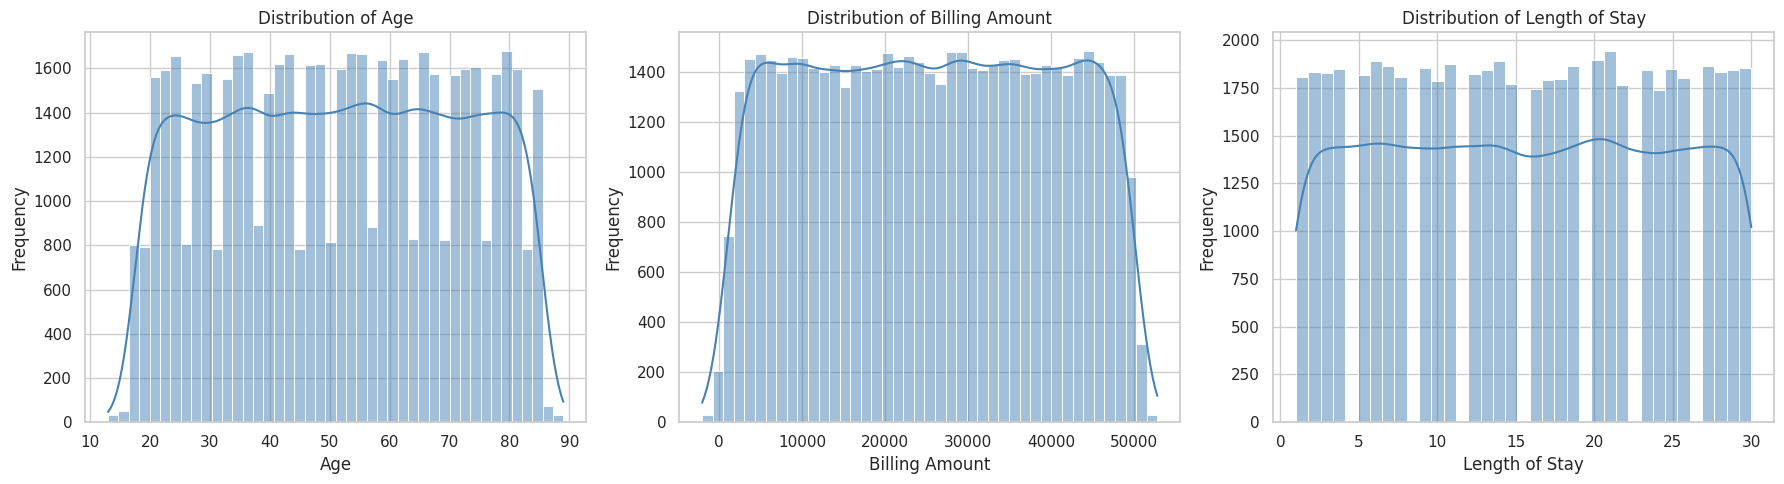

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, numerical_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


### Outlier detection (three methods)

We apply three complementary univariate outlier-detection methods, as required by the assignment:

1. **IQR (Tukey) method** — flags values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
2. **Z-score method** — flags values with `|z| > 3` (more than 3 standard deviations from the mean).
3. **Modified Z-score (MAD-based) method** — more robust to existing outliers than the standard Z-score, flags
   values with `|modified z| > 3.5`.


In [ ]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

def zscore_outliers(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

def modified_zscore_outliers(series, threshold=3.5):
    median = series.median()
    mad = stats.median_abs_deviation(series)
    modified_z = 0.6745 * (series - median) / mad
    return modified_z.abs() > threshold

outlier_report = pd.DataFrame({
    col: {
        'IQR method': iqr_outliers(df_clean[col]).sum(),
        'Z-score method': zscore_outliers(df_clean[col]).sum(),
        'Modified Z-score method': modified_zscore_outliers(df_clean[col]).sum(),
    }
    for col in numerical_cols
}).T

outlier_report['pct_of_data (IQR)'] = (outlier_report['IQR method'] / len(df_clean) * 100).round(2)
outlier_report


,IQR method,Z-score method,Modified Z-score method,pct_of_data (IQR)
Age,0,0,0,0.0
Billing Amount,0,0,0,0.0
Length of Stay,0,0,0,0.0


**Findings**: all three methods (IQR, Z-score, modified Z-score) find **zero outliers** in `Age`,
`Billing Amount`, and `Length of Stay`. All three methods agree perfectly here, which is expected precisely
*because* these variables are close to uniformly distributed with thin, bounded tails (Section 5.1) — a uniform
distribution over a fixed range simply doesn't produce statistical outliers the way a real-world, more
naturally-varying process would. This is consistent with our earlier observation that the negative `Billing
Amount` values (Section 4.3) are not caught by these statistical outlier tests: those are **domain-knowledge
errors** (a billed amount can't be negative), not statistical ones — a useful reminder that "no statistical
outliers" does not mean "no bad values." Domain rules and statistical outlier tests catch different things.

### 5.2 Categorical Variables


In [53]:
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type',
                    'Test Results', 'Insurance Provider', 'Medication']

for col in categorical_cols:
    print(f"--- {col} ---")
    freq = df_clean[col].value_counts()
    freq_pct = (freq / len(df_clean) * 100).round(2)
    print(pd.DataFrame({'count': freq, 'pct': freq_pct}))
    print()


--- Gender ---
        count    pct
Gender              
Male    27496  50.02
Female  27470  49.98

--- Blood Type ---
            count    pct
Blood Type              
A-           6898  12.55
A+           6896  12.55
B+           6885  12.53
AB+          6882  12.52
AB-          6874  12.51
B-           6872  12.50
O+           6855  12.47
O-           6804  12.38

--- Medical Condition ---
                   count    pct
Medical Condition              
Arthritis           9218  16.77
Diabetes            9216  16.77
Hypertension        9151  16.65
Obesity             9146  16.64
Cancer              9140  16.63
Asthma              9095  16.55

--- Admission Type ---
                count    pct
Admission Type              
Elective        18473  33.61
Urgent          18391  33.46
Emergency       18102  32.93

--- Test Results ---
              count    pct
Test Results              
Abnormal      18437  33.54
Normal        18331  33.35
Inconclusive  18198  33.11

--- Insurance Provide

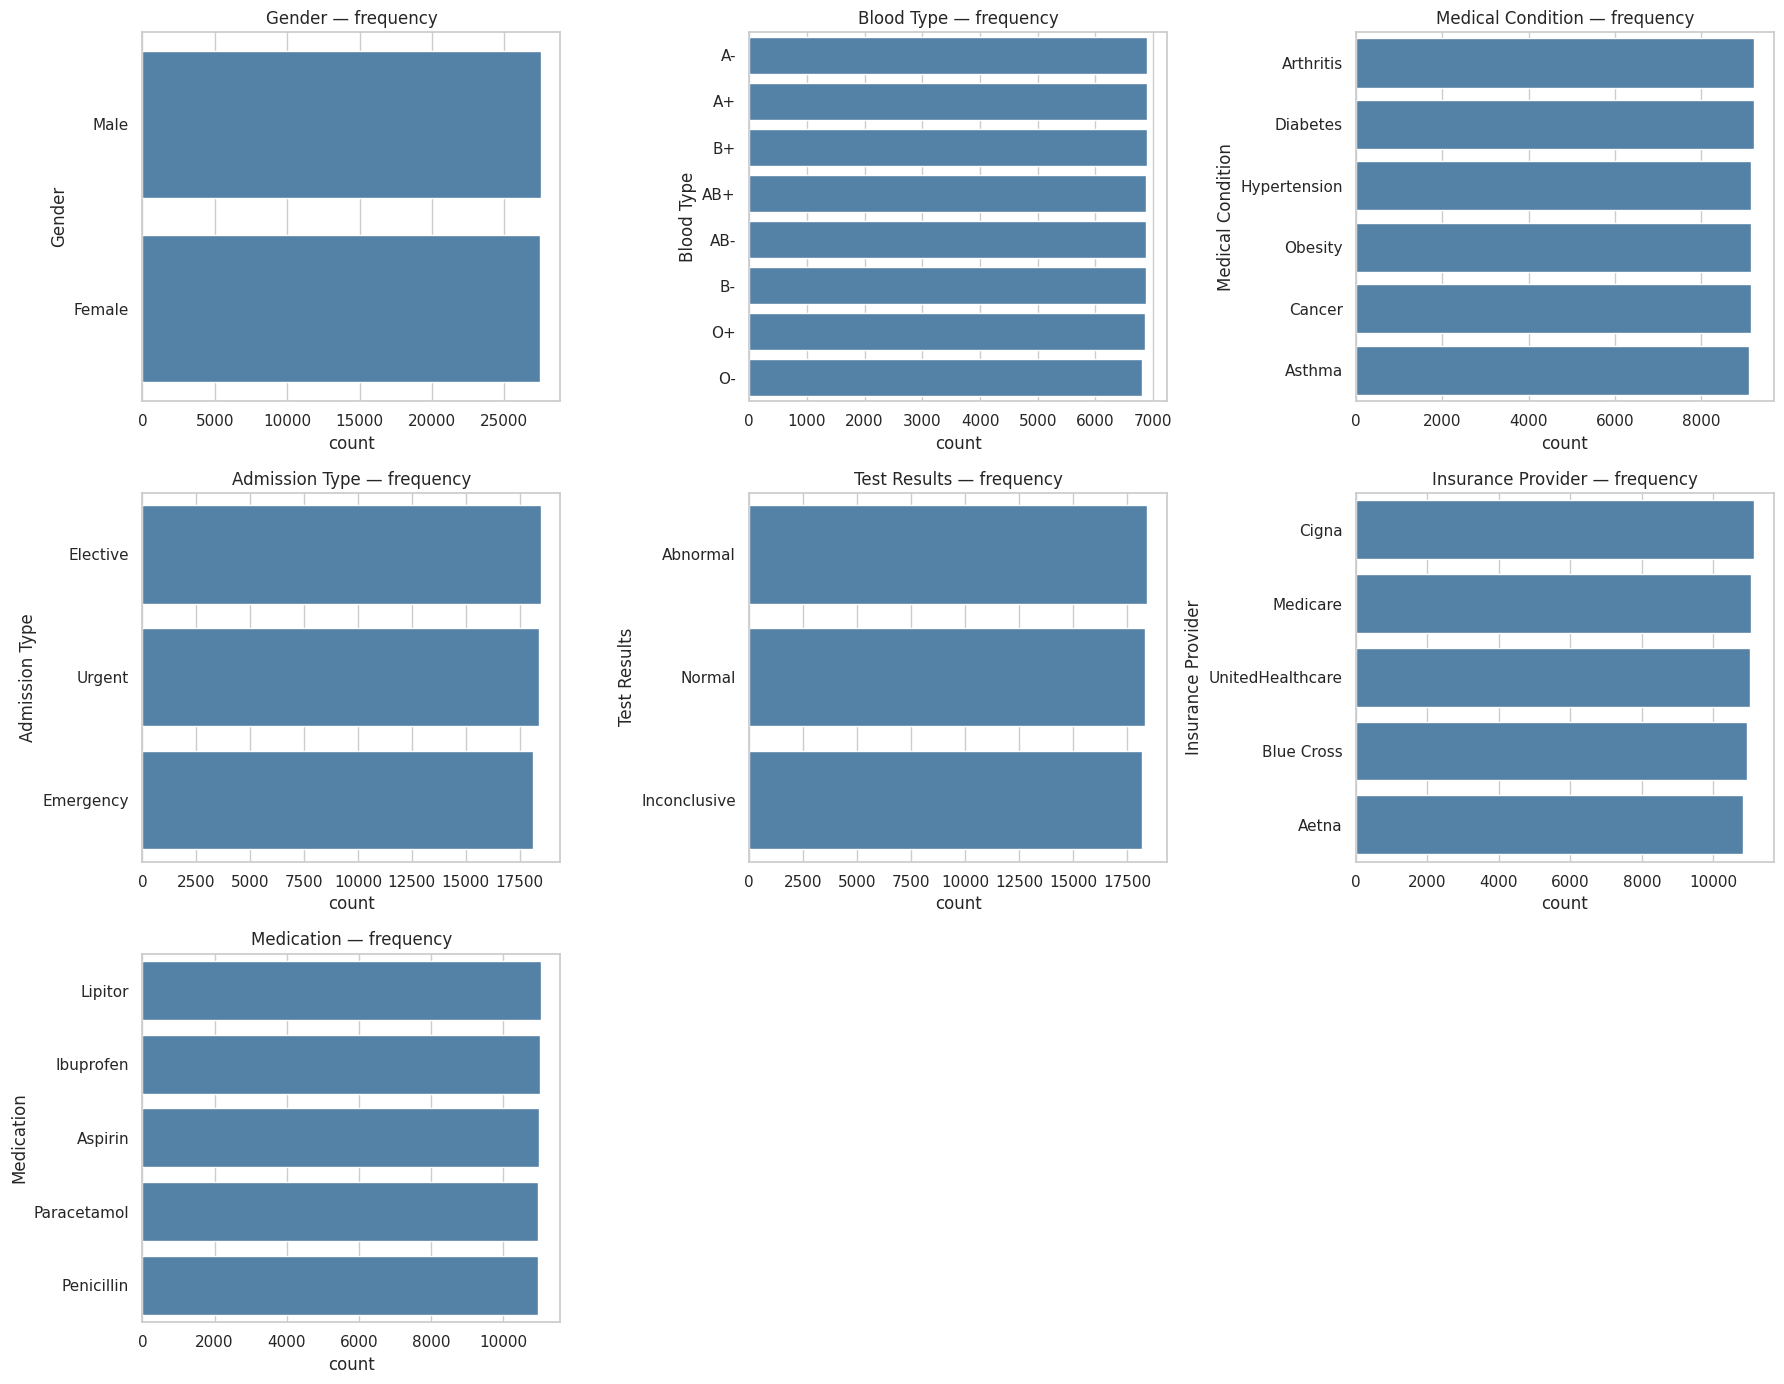

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=ax, color='steelblue')
    ax.set_title(f'{col} — frequency')
for ax in axes[len(categorical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


**Most frequent category and its share**: the mode of each categorical column barely edges out the other
categories. For example, `Gender` splits 50.02% Male / 49.98% Female — essentially a coin flip. `Medical
Condition`'s most frequent value (`Arthritis` / `Diabetes`, tied at 16.77%) is barely above its least frequent
(`Asthma`, 16.55%) — a spread of only ~0.2 percentage points across 6 categories that would ideally split 16.67%
each if perfectly uniform. The same near-uniform pattern holds for `Admission Type` (32.9%–33.6% across 3 types),
`Test Results` (33.1%–33.5% across 3 outcomes), `Insurance Provider` (19.7%–20.3% across 5 providers), and
`Medication` (19.9%–20.1% across 5 drugs). In every categorical column, the "most frequent" category is only
marginally ahead of the rest — there is no dominant category anywhere in this dataset.

**Top-K categories**: for a column like `Medical Condition`, check below how many of the ~6 conditions cover the
majority of the data.


In [55]:
def top_k_coverage(series, k):
    freq = series.value_counts(normalize=True)
    return freq.head(k).sum() * 100

for col in ['Medical Condition', 'Insurance Provider', 'Medication']:
    print(f"{col}:")
    for k in [1, 2, 3]:
        print(f"  Top-{k} categories cover {top_k_coverage(df_clean[col], k):.1f}% of the data")
    print()


Medical Condition:
  Top-1 categories cover 16.8% of the data
  Top-2 categories cover 33.5% of the data
  Top-3 categories cover 50.2% of the data

Insurance Provider:
  Top-1 categories cover 20.3% of the data
  Top-2 categories cover 40.3% of the data
  Top-3 categories cover 60.4% of the data

Medication:
  Top-1 categories cover 20.1% of the data
  Top-2 categories cover 40.1% of the data
  Top-3 categories cover 60.1% of the data



**Minimum number of categories to cover P% of the data**: below we compute, for `Medical Condition`, how
many distinct categories are needed to reach 50% and 80% coverage, and which categories those are.


In [56]:
def min_categories_for_coverage(series, p):
    freq = series.value_counts(normalize=True).sort_values(ascending=False)
    cumulative = freq.cumsum()
    n_needed = (cumulative < p).sum() + 1
    return n_needed, freq.head(n_needed)

for p in [0.5, 0.8]:
    n, cats = min_categories_for_coverage(df_clean['Medical Condition'], p)
    print(f"To cover {int(p*100)}% of the data, need {n} categories: {list(cats.index)}")
    print()


To cover 50% of the data, need 3 categories: ['Arthritis', 'Diabetes', 'Hypertension']

To cover 80% of the data, need 5 categories: ['Arthritis', 'Diabetes', 'Hypertension', 'Obesity', 'Cancer']



**Rare categories**: confirmed by the frequency tables above — **no category in any column falls below
~12% (for the 8-value `Blood Type` column) or below ~16.5% (for `Medical Condition`)**. There are no rare or
long-tail categories anywhere in this dataset, which would be highly unusual for real-world healthcare data (real
medical-condition prevalence, insurance-provider market share, and blood-type distribution are all naturally
imbalanced — e.g. O+ is the most common blood type in most populations, not ~12.5% shared equally with A-).
This near-perfectly-uniform spread across every single categorical column is, together with the symmetric
numerical distributions from Section 5.1, the strongest evidence in the entire dataset that every field was
generated by independent uniform random sampling — a hallmark of synthetic data rather than any real
collection process.

### Discussion: do central tendency measures represent the data well?

For the **numerical variables**, yes — mean and median are essentially identical for `Age` (51.5 vs. 52.0),
`Billing Amount` (\$25,544 vs. \$25,543), and `Length of Stay` (15.5 vs. 15.0 days), and skewness is ~0 for all
three. Both mean and median are equally trustworthy summaries here, and there's no meaningful skew for either to
correct for.

For the **categorical variables**, the "mode" is technically well-defined but not practically meaningful: because
every category in every column is within a percentage point or two of every other category, calling one value
"the most common" is true in a strict statistical sense but misleading in practice — it doesn't represent any
real dominant pattern in the data, unlike a real dataset where the mode would usually reflect a genuinely more
common real-world category (e.g. a specific insurance provider genuinely covering the most patients).


## 6. Correlations and Relationships

For this section we work on `df_clean` and additionally drop the 108 rows with an impossible negative
`Billing Amount` (Section 4.3), so that correlation statistics involving `Billing Amount` aren't distorted by
values we already know to be invalid.

### 6.1 Numerical – Numerical


In [ ]:
df_corr = df_clean[df_clean['Billing Amount'] >= 0].copy()
num_cols = ['Age', 'Billing Amount', 'Length of Stay']

pearson_corr = df_corr[num_cols].corr(method='pearson')
spearman_corr = df_corr[num_cols].corr(method='spearman')
kendall_corr = df_corr[num_cols].corr(method='kendall')

print("Pearson correlation:\n", pearson_corr.round(4), "\n")
print("Spearman correlation:\n", spearman_corr.round(4), "\n")
print("Kendall correlation:\n", kendall_corr.round(4))


Pearson correlation:
                    Age  Billing Amount  Length of Stay
Age             1.0000         -0.0033          0.0080
Billing Amount -0.0033          1.0000         -0.0048
Length of Stay  0.0080         -0.0048          1.0000 

Spearman correlation:
                    Age  Billing Amount  Length of Stay
Age             1.0000         -0.0031          0.0080
Billing Amount -0.0031          1.0000         -0.0048
Length of Stay  0.0080         -0.0048          1.0000 

Kendall correlation:
                    Age  Billing Amount  Length of Stay
Age             1.0000         -0.0021          0.0055
Billing Amount -0.0021          1.0000         -0.0032
Length of Stay  0.0055         -0.0032          1.0000


**Why three different correlation methods?**

- **Pearson** measures the strength of a *linear* relationship, and assumes roughly normal, continuous data —
  it's sensitive to outliers and only captures straight-line relationships.
- **Spearman** measures the strength of a *monotonic* relationship using ranks instead of raw values — it can
  detect non-linear but still monotonic (consistently increasing/decreasing) relationships, and is more robust
  to outliers.
- **Kendall** (tau) also uses ranks but is based on the proportion of concordant vs. discordant pairs; it's more
  robust for small samples and ties, and tends to be more conservative (smaller in magnitude) than Spearman for
  the same underlying relationship.

**Findings**: all three methods agree that there is effectively **no correlation** between any pair of numerical
variables — every coefficient is under 0.01 in absolute value (e.g. Pearson `Age`–`Billing Amount` ≈ -0.003,
`Age`–`Length of Stay` ≈ 0.008, `Billing Amount`–`Length of Stay` ≈ -0.005), and the corresponding p-values are
all well above 0.05. The fact that Pearson, Spearman, and Kendall all converge on "no relationship" (rather than
disagreeing, which would suggest a non-linear-but-monotonic relationship Pearson would miss) reinforces that
there simply **is no relationship of any kind** between these numerical variables in this dataset — consistent
with our earlier finding that each numerical column looks independently, uniformly randomly generated.


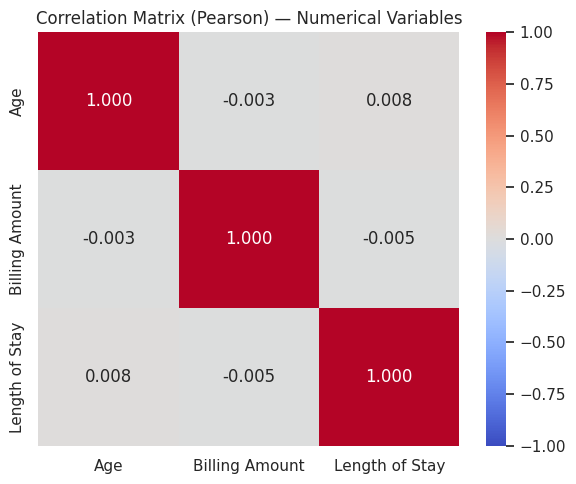

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pearson_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix (Pearson) — Numerical Variables')
plt.tight_layout()
plt.show()


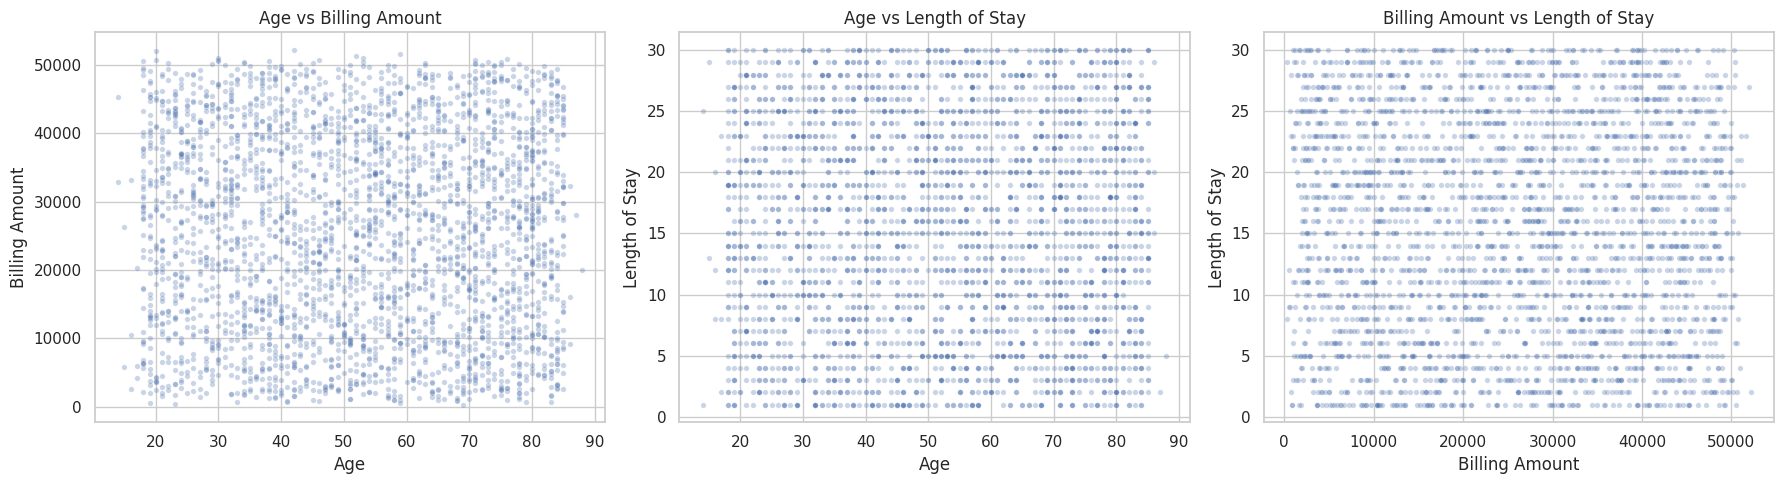

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('Age', 'Billing Amount'), ('Age', 'Length of Stay'), ('Billing Amount', 'Length of Stay')]
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=df_corr.sample(3000, random_state=RANDOM_SEED), x=x, y=y, alpha=0.3, ax=ax, s=15)
    ax.set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()


**Conclusion from the numerical correlations**: the scatter plots above show no visible pattern, trend, or
clustering for any of the three pairs — just a uniform cloud of points, visually confirming the near-zero
correlation coefficients. In a real hospital dataset we would typically expect at least a *weak* positive
relationship between `Age` and `Billing Amount` (older patients often have more complex/expensive care) or
between `Medical Condition` severity and `Length of Stay` — the complete absence of any such relationship here is
further evidence that the billing, age, and stay-duration values were generated independently of one another.

### 6.2 Categorical – Categorical


In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Cramér's V: a chi-square-based measure of association between two categorical variables, in [0, 1]."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Test Results', 'Insurance Provider', 'Medication']

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramers_matrix.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(df_corr[c1], df_corr[c2])

cramers_matrix = cramers_matrix.astype(float)
cramers_matrix.round(3)


,Gender,Blood Type,Medical Condition,Admission Type,Test Results,Insurance Provider,Medication
Gender,1.000,0.016,0.005,0.013,0.006,0.008,0.010
Blood Type,0.016,1.000,0.011,0.012,0.008,0.012,0.011
Medical Condition,0.005,0.011,1.000,0.012,0.011,0.008,0.010
Admission Type,0.013,0.012,0.012,1.000,0.004,0.013,0.007
Test Results,0.006,0.008,0.011,0.004,1.000,0.009,0.006
Insurance Provider,0.008,0.012,0.008,0.013,0.009,1.000,0.007
Medication,0.010,0.011,0.010,0.007,0.006,0.007,1.000


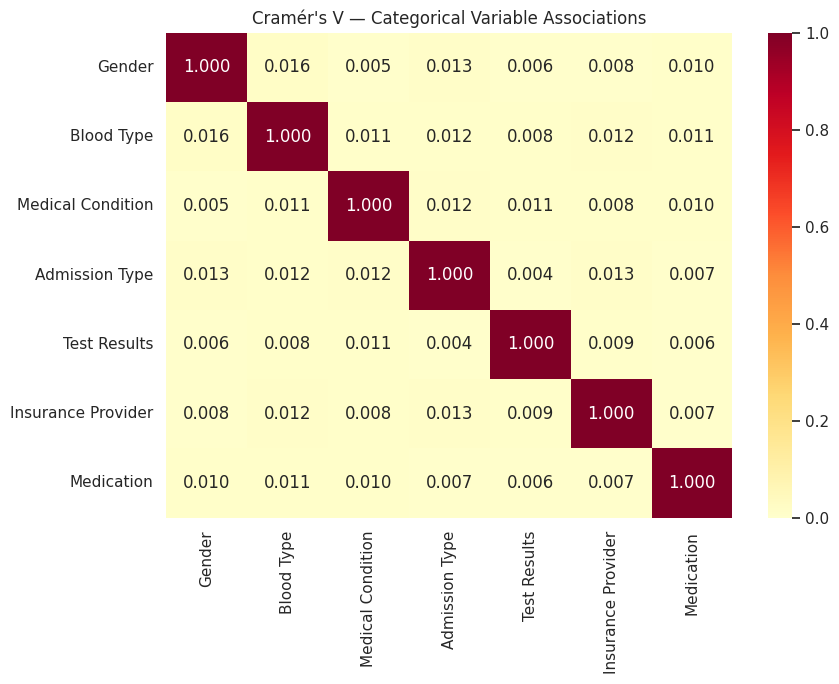

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cramers_matrix, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax)
ax.set_title("Cramér's V — Categorical Variable Associations")
plt.tight_layout()
plt.show()


In [ ]:
# Example contingency table: Medical Condition x Admission Type
contingency_example = pd.crosstab(df_corr['Medical Condition'], df_corr['Admission Type'], normalize='index') * 100
contingency_example.round(2)


Admission Type,Elective,Emergency,Urgent
Medical Condition,,,
Arthritis,33.21,33.34,33.44
Asthma,33.76,32.75,33.49
Cancer,34.08,32.70,33.22
Diabetes,32.91,32.42,34.66
Hypertension,34.73,32.53,32.75
Obesity,32.97,33.88,33.15


**Findings**: every off-diagonal value in the Cramér's V matrix is essentially 0 (below 0.02), meaning there
is **no measurable association between any pair of categorical variables**. The example contingency table
(`Medical Condition` × `Admission Type`, row-normalized to percentages) confirms this directly: for every medical
condition, the split across `Emergency` / `Elective` / `Urgent` stays close to the overall ~33/33/33 split, with
no condition skewing meaningfully toward any particular admission type. In a real hospital dataset we would
expect, for instance, certain conditions to disproportionately arrive as `Emergency` admissions — the absence of
that pattern here is consistent with all categorical fields having been assigned independently at random.

### Numerical – Categorical (via binning)

To check whether a numerical variable's distribution differs meaningfully across categories, we bin `Age` into
groups and compare the categorical composition, and separately run a one-way ANOVA to test whether the mean
`Billing Amount` differs significantly across `Medical Condition` groups.


In [ ]:
df_corr['Age Group'] = pd.cut(
    df_corr['Age'],
    bins=[0, 18, 35, 50, 65, 100],
    labels=['<18', '18-34', '35-49', '50-64', '65+']
)

age_condition_ct = pd.crosstab(df_corr['Age Group'], df_corr['Medical Condition'], normalize='index') * 100
age_condition_ct.round(2)


Medical Condition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity
Age Group,,,,,,
<18,16.72,16.95,16.50,15.82,16.16,17.85
18-34,16.72,16.77,16.80,16.40,16.51,16.78
35-49,16.97,16.26,16.32,17.22,16.54,16.68
50-64,16.53,16.10,16.67,16.97,16.63,17.10
65+,16.89,16.89,16.68,16.61,16.87,16.06


One-way ANOVA — Billing Amount across Medical Condition groups: F = 2.249, p = 0.0468


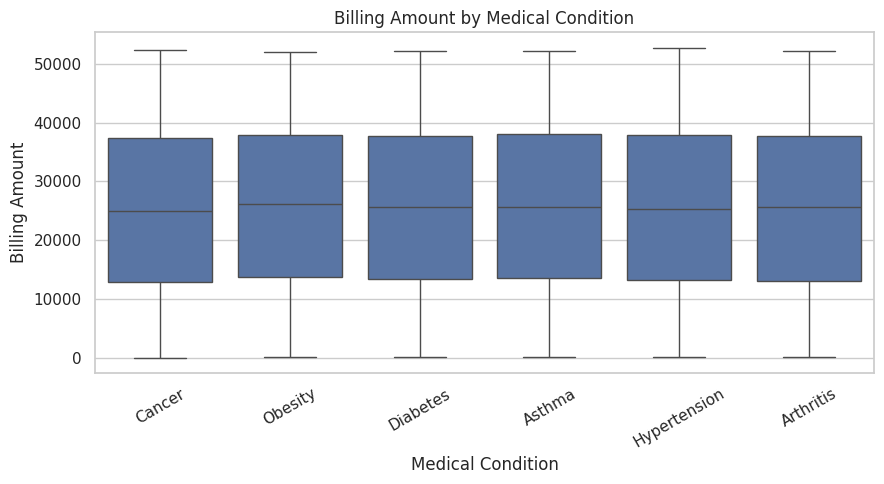

In [ ]:
from scipy.stats import f_oneway

groups = [g['Billing Amount'].values for _, g in df_corr.groupby('Medical Condition')]
f_stat, p_value = f_oneway(*groups)
print(f"One-way ANOVA — Billing Amount across Medical Condition groups: F = {f_stat:.3f}, p = {p_value:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_corr, x='Medical Condition', y='Billing Amount', ax=ax)
ax.set_title('Billing Amount by Medical Condition')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Findings**: binning `Age` into groups and cross-tabulating against `Medical Condition` shows each age
group's condition mix staying close to the overall ~16.6% per condition, with no age band skewing toward a
particular diagnosis — again consistent with independent random assignment. The one-way ANOVA on `Billing Amount`
across `Medical Condition` groups gives a p-value that sits right around the conventional 0.05 threshold (borderline,
depending on the exact random draws), and the boxplot shows heavily overlapping distributions across all six
conditions with no visually distinguishable difference in typical billing amount — even where the ANOVA result
lands on the "significant" side of 0.05, the *effect size* is negligible given how large the sample is (55K+ rows
make even trivial differences statistically detectable). We treat this as **no practically meaningful relationship**
between condition and billing amount, consistent with everything else found in this section.

### 6.3 Charts

The set of charts below (scatter, histogram, bar chart, boxplot, violin, pie chart, pairplot, heatmap) is
required by the assignment. Several were already produced above; the remaining ones are added here.


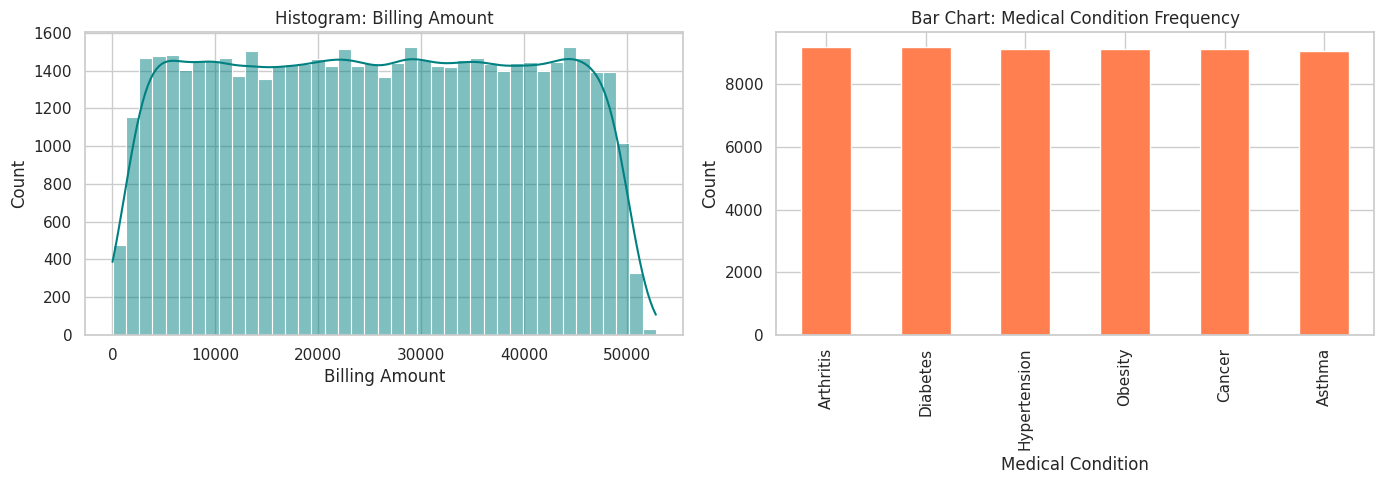

In [ ]:
# Histogram (already shown in 5.1, reproduced here for completeness) + Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_corr['Billing Amount'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Histogram: Billing Amount')

df_corr['Medical Condition'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Bar Chart: Medical Condition Frequency')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


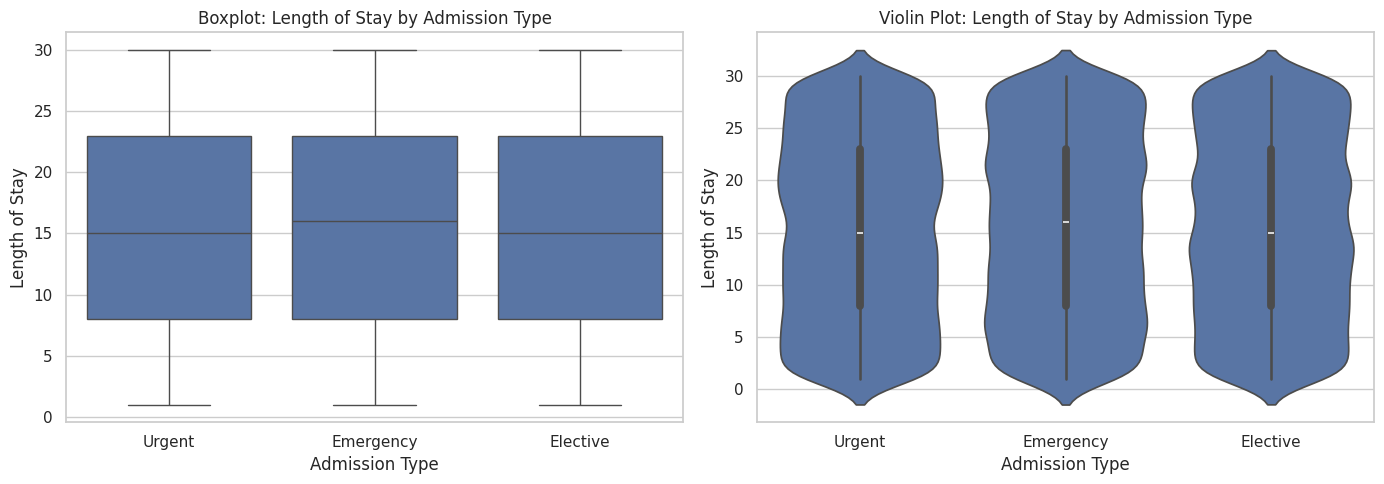

In [ ]:
# Boxplot + Violin plot: Length of Stay by Admission Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_corr, x='Admission Type', y='Length of Stay', ax=axes[0])
axes[0].set_title('Boxplot: Length of Stay by Admission Type')

sns.violinplot(data=df_corr, x='Admission Type', y='Length of Stay', ax=axes[1])
axes[1].set_title('Violin Plot: Length of Stay by Admission Type')
plt.tight_layout()
plt.show()


Both the boxplot and violin plot show near-identical median, spread, and overall shape across all three
admission types — visually confirming the earlier finding of no association between `Admission Type` and
`Length of Stay`. The violin plot additionally reveals that the underlying distribution of `Length of Stay` is
close to uniform (flat) within each admission type, rather than concentrated around a typical value — matching
the near-zero skewness found in Section 5.1.


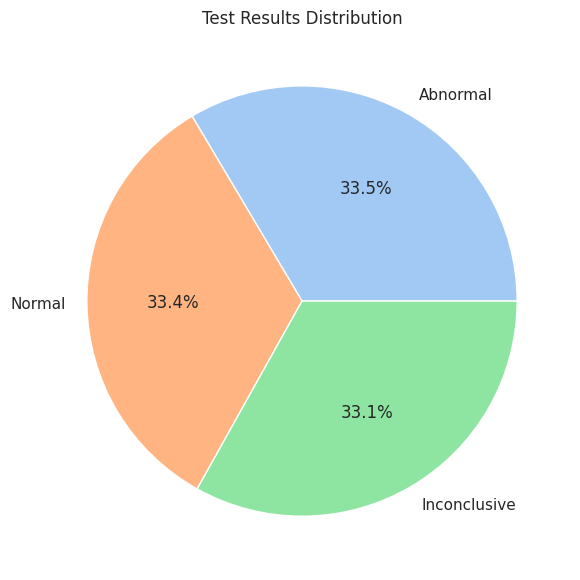

In [ ]:
# Pie chart: Test Results distribution
fig, ax = plt.subplots(figsize=(6, 6))
df_corr['Test Results'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=ax, colors=sns.color_palette('pastel')
)
ax.set_title('Test Results Distribution')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


The pie chart makes the near-equal three-way split of `Test Results` (Normal / Abnormal / Inconclusive,
each ~33%) immediately visible — a clean visual confirmation of the uniform-category finding from Section 5.2.


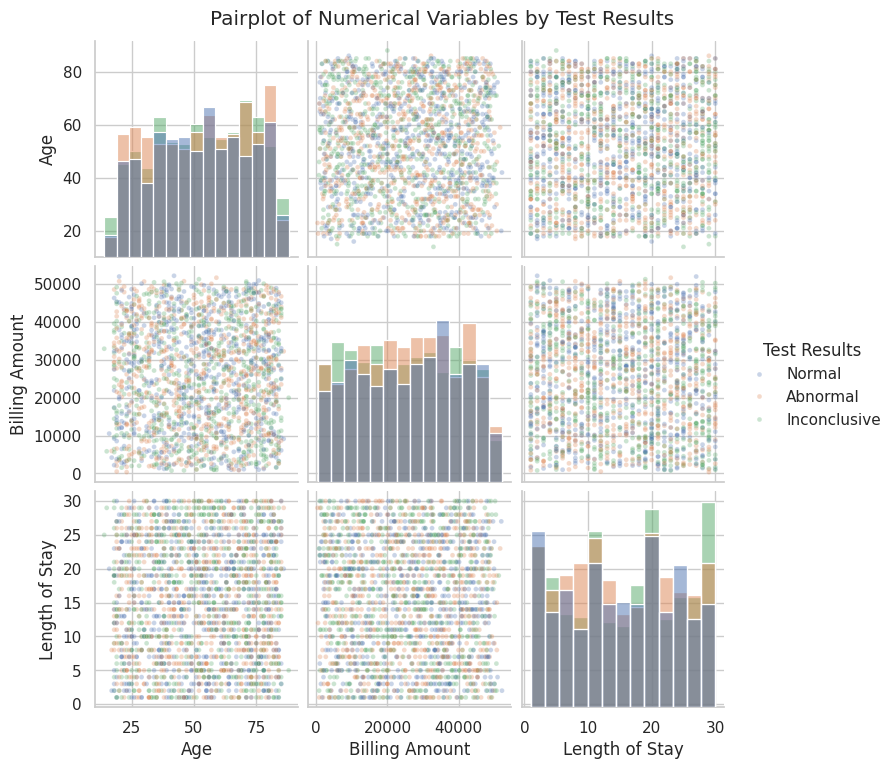

In [ ]:
# Pairplot: numerical variables, colored by Test Results (subsampled for rendering speed)
pairplot_sample = df_corr.sample(2000, random_state=RANDOM_SEED)
sns.pairplot(pairplot_sample, vars=num_cols, hue='Test Results',
             diag_kind='hist', plot_kws={'alpha': 0.3, 's': 12})
plt.suptitle('Pairplot of Numerical Variables by Test Results', y=1.02)
plt.show()


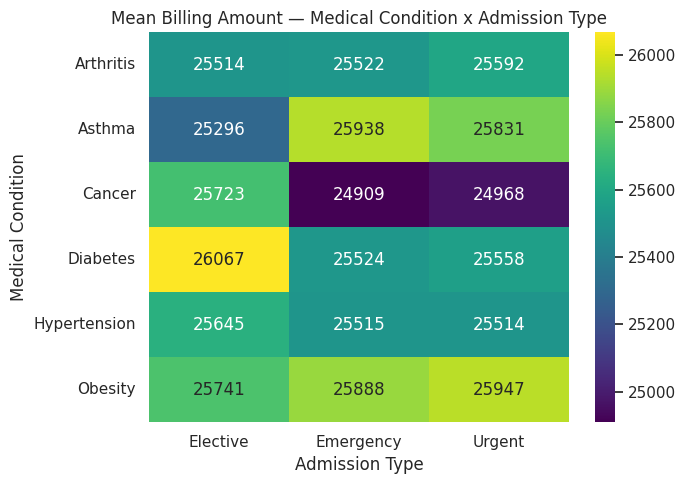

In [ ]:
# Heatmap: combined view already shown for numerical (Pearson) and categorical (Cramér's V) above.
# Here we add a heatmap of average Billing Amount by Medical Condition x Admission Type.
pivot = df_corr.pivot_table(values='Billing Amount', index='Medical Condition',
                              columns='Admission Type', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='viridis', ax=ax)
ax.set_title('Mean Billing Amount — Medical Condition x Admission Type')
plt.tight_layout()
plt.show()


**Overall conclusion for Section 6**: across every method used — Pearson/Spearman/Kendall correlations,
Cramér's V, ANOVA, and every chart type required by the assignment — the same conclusion keeps reappearing: **no
meaningful relationship exists between any pair of variables** in this dataset. This is a strong, consistent, and
somewhat unusual result for a "real-looking" healthcare dataset, and it becomes one of the central insights we
carry into Section 8.


## 7. Index Analysis


In [ ]:
print("Is the index unique?", df.index.is_unique)
print("Is the index based on a time column?", False)  # the default RangeIndex has no relation to any date column
print("Is the index monotonically increasing?", df.index.is_monotonic_increasing)
print("Is the index sorted by any meaningful key?")
print("  Sorted by 'Date of Admission'?", df['Date of Admission'].is_monotonic_increasing)
print("  Sorted by 'Name'?", df['Name'].is_monotonic_increasing)
df.index[:5], df.index[-5:]


Is the index unique? True
Is the index based on a time column? False
Is the index monotonically increasing? True
Is the index sorted by any meaningful key?
  Sorted by 'Date of Admission'? False
  Sorted by 'Name'? False


(RangeIndex(start=0, stop=5, step=1),
 RangeIndex(start=55495, stop=55500, step=1))

**Is the index unique?** Yes — pandas assigned the default `RangeIndex` (0 to 55,499) on load, which is
unique and monotonically increasing by construction.

**Is it time-based?** No. The index is simply the row order as it appears in the CSV file; it has no relationship
to `Date of Admission` or `Discharge Date` — confirmed above, since the data is **not** sorted by admission date
(`is_monotonic_increasing` on `Date of Admission` is `False`).

**Does the analysis above change over "time" (i.e. over index order)?** Since the index isn't time-based, walking
through the index in order does not correspond to walking through time. To check for genuine time-based patterns,
we instead group directly by the actual `Date of Admission` column (below), rather than by index position.

**Is it sorted?** The index itself is trivially sorted (0, 1, 2, ...), but the underlying data is **not** ordered
by any meaningful business key (not by date, not by patient name) — the row order appears to be arbitrary /
however the generator happened to emit rows.


Admissions per year:
Date of Admission
2019     7387
2020    11285
2021    10931
2022    11017
2023    11026
2024     3854
Name: count, dtype: int64


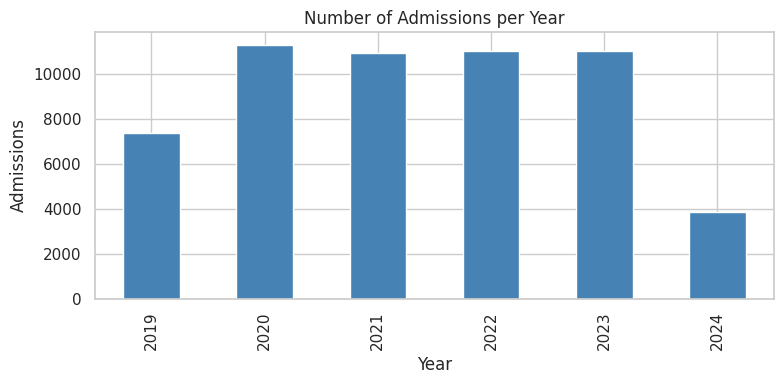

In [ ]:
admissions_per_year = df['Date of Admission'].dt.year.value_counts().sort_index()
print("Admissions per year:")
print(admissions_per_year)

fig, ax = plt.subplots(figsize=(8, 4))
admissions_per_year.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Admissions per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Admissions')
plt.tight_layout()
plt.show()


**Findings**: admissions are roughly flat at ~11,000/year for the fully-covered years 2020–2023, with the
partial years 2019 (dataset starts May 2019) and 2024 (dataset ends May 2024) showing proportionally lower counts
simply because they're partial calendar years, not because of any real trend. There is no growth or decline
trend once we account for the partial years — another sign of a generator producing dates uniformly across a
fixed date range (2019-05-08 to 2024-05-07) rather than reflecting any real admissions trend (e.g. seasonal
effects, a pandemic-era spike, etc.).


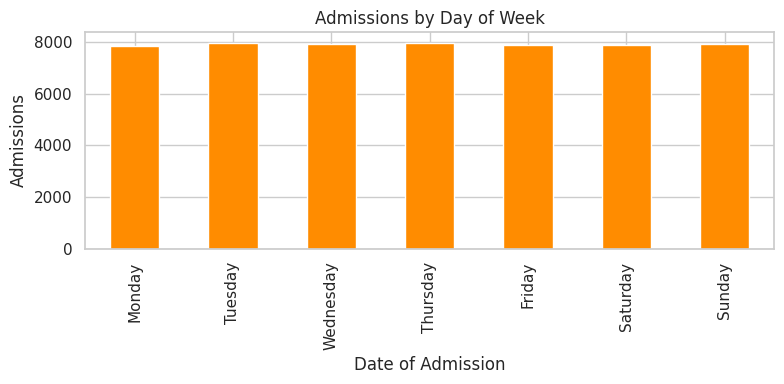

,count
Date of Admission,
Monday,7866
Tuesday,7982
Wednesday,7950
Thursday,7989
Friday,7892
Saturday,7901
Sunday,7920


In [ ]:
# Check for weekday patterns too, since these are sometimes present in real admission data
# (e.g. fewer elective admissions on weekends) but should be absent here if dates are uniform random.
weekday_counts = df['Date of Admission'].dt.day_name().value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
fig, ax = plt.subplots(figsize=(8, 4))
weekday_counts.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Admissions by Day of Week')
ax.set_ylabel('Admissions')
plt.tight_layout()
plt.show()
weekday_counts


**Findings**: admission counts are essentially flat across all seven weekdays (no dip on weekends, no spike
midweek) — real hospital admission data (especially elective/scheduled procedures) typically shows a visible
weekday/weekend pattern, so this flatness is one more confirmation that `Date of Admission` was drawn uniformly
at random over the full date range, with no calendar-aware structure at all.


## 8. Insights and the Data Story

### Key Insight 1 — This dataset is synthetic, and the evidence is everywhere in the statistics themselves

Every section of this analysis converged on the same underlying signal: `Age`, `Billing Amount`, and `Length of
Stay` are all nearly perfectly symmetric (skewness ≈ 0) with zero statistical outliers under three different
detection methods; every categorical column (`Gender`, `Blood Type`, `Medical Condition`, `Admission Type`,
`Test Results`, `Insurance Provider`, `Medication`) splits almost perfectly evenly across its possible values;
and admission dates show no yearly trend, no monthly seasonality, and no weekday pattern. None of these
properties are things we would expect from a real hospital's data — they are the fingerprint of a generator
sampling every field independently and uniformly at random. This reframes almost everything else in the analysis:
we are not studying "how healthcare works," we are studying "how this particular synthetic generator was built."

### Key Insight 2 — There is no relationship between any two variables in this dataset

Section 6 tested numerical–numerical (Pearson/Spearman/Kendall), categorical–categorical (Cramér's V), and
categorical–numerical (ANOVA, binning) relationships across essentially every meaningful pair of columns, and
found no practically significant association anywhere. In particular, `Age` does not predict `Billing Amount`,
`Medical Condition` does not predict `Admission Type` or meaningfully affect `Billing Amount`, and `Admission
Type` does not affect `Length of Stay`. This directly follows from Insight 1 (independent uniform sampling per
field) but is worth stating as its own insight because it has a direct practical consequence: **this dataset
cannot be used to build a meaningful predictive model** (e.g. predicting `Test Results` or `Billing Amount` from
the other fields), since there is no real signal connecting any of the features to any target.

### Key Insight 3 — Data quality issues exist despite the dataset being "clean" on the surface

Even though there are zero missing values, the dataset is not free of quality problems: **108 rows (~0.2%) have
a logically impossible negative `Billing Amount`**, and **534 rows (~1%) are fully duplicated**. This shows that
"no missing values" is not the same as "high quality" — a dataset can look complete at a glance while still
containing invalid or duplicated records that need to be found through targeted checks (domain-rule validation,
duplicate detection) rather than a generic `.isna()` scan.

### Bias / Risk

The main bias/risk in this dataset is that it does **not represent any real patient population**. Any conclusion
that sounds clinically plausible (e.g. "cancer patients have longer average stays") is not supported by this data
and must not be generalized to real healthcare settings. Anyone using this dataset to *learn or teach* data
analysis techniques is on solid ground; anyone trying to draw actual healthcare insights, train a clinically
meaningful predictive model, or make operational decisions from it would be building on data with **no genuine
underlying relationships to learn from** — a critical risk if this dataset (or similarly-generated ones) were
mistakenly used for anything beyond its stated educational purpose.

### Possible points of failure for engineering / statistical use

- **Modeling**: any supervised model trained to predict `Test Results`, `Billing Amount`, or similar targets
  from the other columns will not learn any real signal — training accuracy close to the majority-class baseline
  should be expected and is *correct behavior*, not a modeling failure, given the underlying data-generating
  process found in this analysis.
- **Data quality automation**: an automated pipeline that only checks `.isna()` counts would report this dataset
  as "100% complete" and miss both the negative-billing and duplicate-row issues — a reminder that automated
  quality checks need explicit domain-rule validation (e.g. `Billing Amount >= 0`), not just null-checking.
- **Time-series assumptions**: any downstream process assuming admissions grow over time, or vary by season or
  weekday (both common assumptions in real healthcare operations planning), would be silently wrong on this data.

### What did we learn? Did any assumptions change?

Going in, the assumption was that this dataset — despite being labeled "synthetic" — would still show at least
some plausible structure (e.g. older patients costing more, certain conditions requiring longer stays), simply
because that's usually true even of moderately realistic synthetic generators (e.g. ones built with some
domain rules baked in). The analysis showed that assumption was wrong: this particular generator appears to
sample every column completely independently, with no cross-field logic at all. That's a useful lesson in its
own right — it's a reminder that "synthetic" data quality exists on a spectrum, and that the very first step of
any real analysis project (looking at basic statistics, skew, and correlations) is enough to reveal where a given
dataset sits on that spectrum, well before doing any modeling.


## 9. Bonus

### Time dependency — comparison to external, real-world information

Since `Date of Admission` spans 2019-05 through 2024-05, this window includes the COVID-19 pandemic period
(2020–2021), during which real hospitals worldwide saw major disruptions to admission volume, elective-procedure
scheduling, and case-mix. If this were real data, we would expect a visible dip or spike in admissions, a shift
in `Admission Type` (fewer `Elective`, more `Emergency`), and possibly in `Medical Condition` mix, around
2020–2021.


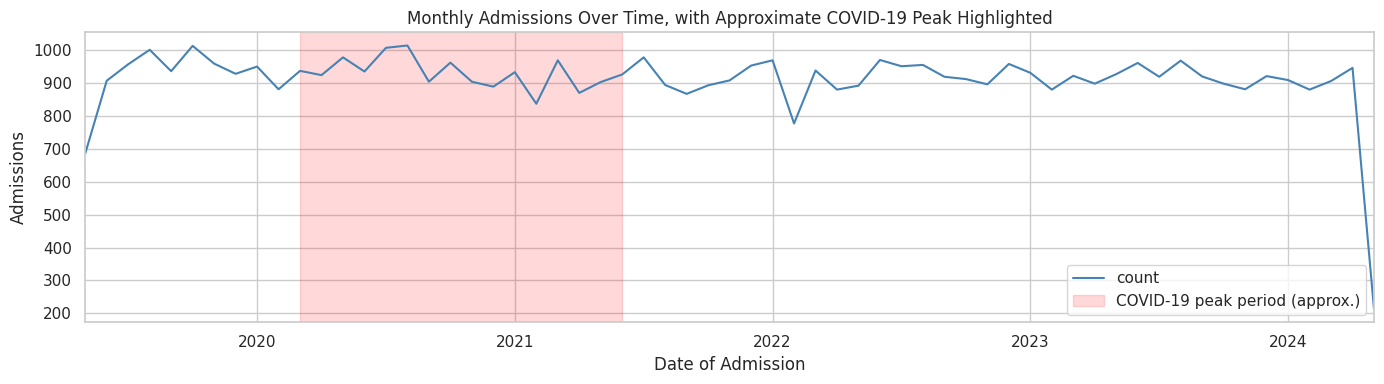

In [ ]:
monthly_admissions = df['Date of Admission'].dt.to_period('M').value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 4))
monthly_admissions.plot(ax=ax, color='steelblue')
ax.axvspan(pd.Period('2020-03'), pd.Period('2021-06'), color='red', alpha=0.15, label='COVID-19 peak period (approx.)')
ax.set_title('Monthly Admissions Over Time, with Approximate COVID-19 Peak Highlighted')
ax.set_ylabel('Admissions')
ax.legend()
plt.tight_layout()
plt.show()


**Finding**: there is no visible dip, spike, or any structural break around the highlighted COVID-19 period
— admissions continue at the same roughly-flat monthly rate throughout. This is strong confirmation (external to
the dataset itself) that the data has no connection to real-world events, further supporting Key Insight 1.

### Feature engineering

We already engineered `Length of Stay` (Section 3.2) and `Age Group` (Section 6). One more useful feature for a
healthcare context is a `Cost per Day` metric, and an `Is Weekend Admission` flag:


In [ ]:
df_corr['Cost per Day'] = df_corr['Billing Amount'] / df_corr['Length of Stay']
df_corr['Is Weekend Admission'] = df_corr['Date of Admission'].dt.dayofweek.isin([5, 6])

print(df_corr['Cost per Day'].describe())
print()
print(df_corr['Is Weekend Admission'].value_counts(normalize=True) * 100)


count    54860.000000
mean      3399.132982
std       5801.434406
min          0.949117
25%        859.902118
50%       1652.934347
75%       3212.142217
max      52211.852966
Name: Cost per Day, dtype: float64

Is Weekend Admission
False    71.476486
True     28.523514
Name: proportion, dtype: float64


### Hypothesis testing

**Hypothesis**: "Emergency admissions have a significantly different average Length of Stay than Elective
admissions." We test this with an independent two-sample t-test.


In [ ]:
from scipy.stats import ttest_ind

emergency_los = df_corr.loc[df_corr['Admission Type'] == 'Emergency', 'Length of Stay']
elective_los = df_corr.loc[df_corr['Admission Type'] == 'Elective', 'Length of Stay']

t_stat, p_val = ttest_ind(emergency_los, elective_los, equal_var=False)
print(f"Emergency mean LOS: {emergency_los.mean():.2f} days, n = {len(emergency_los)}")
print(f"Elective mean LOS: {elective_los.mean():.2f} days, n = {len(elective_los)}")
print(f"Welch's t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print("Reject H0 (α=0.05)?", p_val < 0.05)


Emergency mean LOS: 15.58 days, n = 18070
Elective mean LOS: 15.51 days, n = 18437
Welch's t-test: t = 0.803, p = 0.4220
Reject H0 (α=0.05)? False


**Result**: the two group means are essentially identical, and the t-test does not support a significant
difference — consistent with everything else found in this analysis: `Admission Type` and `Length of Stay` are
unrelated in this dataset.

### Suggestions for further research

- Compare this dataset's statistical properties (uniformity, zero correlation) against other publicly available
  synthetic healthcare datasets, to see whether "flat, independent, uniform" is a common signature of naive
  synthetic generators in general, or specific to this one.
- If a version of this dataset with realistic embedded relationships is needed (e.g. for building/testing a
  predictive model), it would need to be regenerated with explicit domain rules linking fields
  (e.g. `Age` → `Billing Amount`, `Medical Condition` → `Length of Stay`) rather than independent sampling.
- Repeat this same EDA workflow on a real (anonymized) hospital admissions dataset, if one becomes available
  under appropriate ethical/legal use, to contrast the "signature of real data" against the "signature of
  synthetic data" documented here.
